In [6]:


import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

import pickle
import numpy as np
import math
from Camera import Camera
from Frame import Frame
import matplotlib.pyplot as plt
import Utils
%matplotlib qt



from Frame import Frame

path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov7_2024_11_12_darkan/'

# D:\Documents\data_for_gs\bee\images

path = 'D:/Documents/data_for_gs/mov1_2023_08_09_60ms/'

# path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov30_2024_11_12_darkan/'

frames = list(range(370,470,1))
image_name= []
for frame in frames:
    image_name += [f'P{frame}CAM{cam + 1}' for cam in range(4)]

frames = {f'{im_name}.jpg':Frame(path,im_name,idx, camera_path = path,delta_xy = 80, use_mask = False) for idx,im_name in enumerate(image_name)}


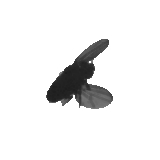

In [2]:
frames['P912CAM4.jpg'].im

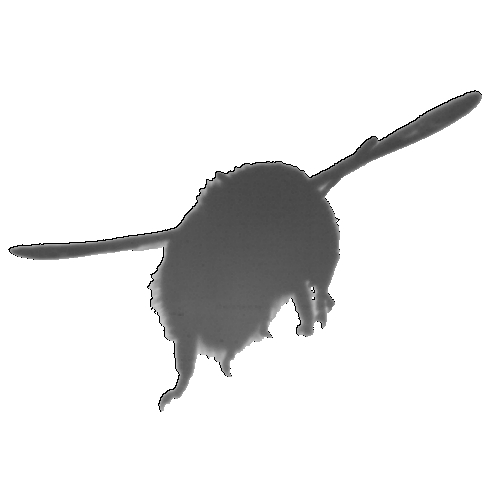

In [83]:
Frame(path,image_name[403],0, camera_path = path,delta_xy = 250, use_mask = True).im

In [2]:

import plotly.graph_objects as go

frames['P1400CAM1.jpg'].R[:,2]

rot_z = frames['P1400CAM1.jpg'].rotation_matrix_from_vectors(frames['P1400CAM1.jpg'].R[2,:], [0,0,1])

rot_z @ frames['P1400CAM1.jpg'].R 


center_cam = np.hstack([rot_z @ frame.X0 for frame in list(frames.values())[0:4]]).T

import Plotters
fig = go.Figure()
Plotters.scatter3d(fig,center_cam,'red',10,'centers')

KeyError: 'P1400CAM1.jpg'

In [25]:
frame.path

'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov7_2024_11_12_darkan/'

In [7]:

frames_dict = {}
for frame_number in range(370,470):
    cams,base_images = {},{}
    for idx in range(4):
        frame_name = f'P{frame_number}CAM{idx+1}.jpg'
        frame = frames[frame_name]
        base_images[frame.image_id] = frame.generate_base_image()
        frame.save_croped_images()
        cams[frame.camera_number] = frame.cams_for_gs()
        if idx == 0:
            rot_z = frames[frame_name].rotation_matrix_from_vectors(frames[frame_name].R[2,:], [0,0,1])
        cams[frame.camera_number]['ew_to_lab'] = rot_z
        cams[frame.camera_number]['bounding_box'] = frame.bounding_box
        
    frames_dict[frame_number] = [base_images,cams,[]]

Utils.pickle_file(frames_dict,f'{frame.path}/frames_model.pkl' )


In [5]:
frames['P370CAM1.jpg'].bounding_box

array([538, 713, 698, 873])

In [50]:
frames_dict[1400][1][0]['ew_to_lab']

array([[ 0.99979039,  0.01822399, -0.00933071],
       [ 0.01822399, -0.58443755,  0.81123402],
       [ 0.00933071, -0.81123402, -0.58464716]])